In [1]:
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.datasets.universal_dataset import GPTDataset
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path

import os
import matplotlib.pyplot as plt

In [2]:
def load_data(drop_inhib: str):
    prep = Pipeline(
        num_cycle=[1, 2, 3, 4], 
        inhibitor_name="all", 
        split="all",
        norm_feat=True
    )
    data = prep.full_data

    train_data, valid_data = select_test_inh(data, drop_inhib)
    
    return train_data, valid_data

In [3]:
INHIBITOR_NAME = "benzimidazole"
normalize = False

train, val = load_data(drop_inhib=INHIBITOR_NAME)

train_dataset = GPTDataset(train)
val = val.iloc[[850, 700, 600, 550, 500, 400, 350, 300, 150, 100], :]
test_dataset = GPTDataset(val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [4]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"


config = {'d_model': 40, 'num_layers': 4, 'num_heads': 1, 'dropout': 0.13811901208562471, 'lr': 0.005915728054852897}
# config = {'d_model': 24, 'num_layers': 3, 'num_heads': 2, 'dropout': 0.10313868900781498, 'lr': 0.0034117457369006}

vae = GPT(
    chem_dim=train_dataset[0]['features'].shape[0],
    conc_dim=train_dataset[0]['conc'].shape[0],
    seq_len=train_dataset[0]['vah'].shape[0],
    d_model=config['d_model'],
    nhead=config['num_heads'],
    num_layers=config['num_layers'],
    dropout=config['dropout']
).to(device)

opt_vae = torch.optim.Adam(vae.parameters(), lr=config['lr'])
scheduler = StepLR(opt_vae, gamma=0.85, step_size=15)

/home/smirnov@dohod.local/work/electrochem-digital-twins-1/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
num_epoch = 100

trainer = Trainer(
    model=vae,
    loss_fn=vae_loss,
    epochs=num_epoch,
    optimizer=opt_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    path_to_save_plots=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    path_to_save_models=os.path.join(get_project_path(), "models", "gpt", INHIBITOR_NAME),
    path_to_save_tables=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    scheduler=scheduler,
    seed=42
)

In [6]:
trainer.train_model()

Epoch 000 — Train Loss: 0.355933, Val Loss: 2.173957, LR: [0.005915728054852897]
Epoch 001 — Train Loss: 0.089366, Val Loss: 2.314854, LR: [0.005915728054852897]
Epoch 002 — Train Loss: 0.044299, Val Loss: 0.499220, LR: [0.005915728054852897]
Epoch 003 — Train Loss: 0.029507, Val Loss: 0.484850, LR: [0.005915728054852897]
Epoch 004 — Train Loss: 0.021554, Val Loss: 3.160317, LR: [0.005915728054852897]
Epoch 005 — Train Loss: 0.017393, Val Loss: 3.328224, LR: [0.005915728054852897]
Epoch 006 — Train Loss: 0.014942, Val Loss: 0.285689, LR: [0.005915728054852897]
Epoch 007 — Train Loss: 0.013197, Val Loss: 0.216252, LR: [0.005915728054852897]
Epoch 008 — Train Loss: 0.011828, Val Loss: 0.214954, LR: [0.005915728054852897]
Epoch 009 — Train Loss: 0.010681, Val Loss: 0.205199, LR: [0.005915728054852897]
Epoch 010 — Train Loss: 0.009720, Val Loss: 0.193747, LR: [0.005915728054852897]
Epoch 011 — Train Loss: 0.008927, Val Loss: 0.200260, LR: [0.005915728054852897]
Epoch 012 — Train Loss: 0.00

In [7]:
vae.load_state_dict(torch.load(os.path.join(get_project_path(), "models", "gpt", INHIBITOR_NAME, "best_model.pt")))

<All keys matched successfully>

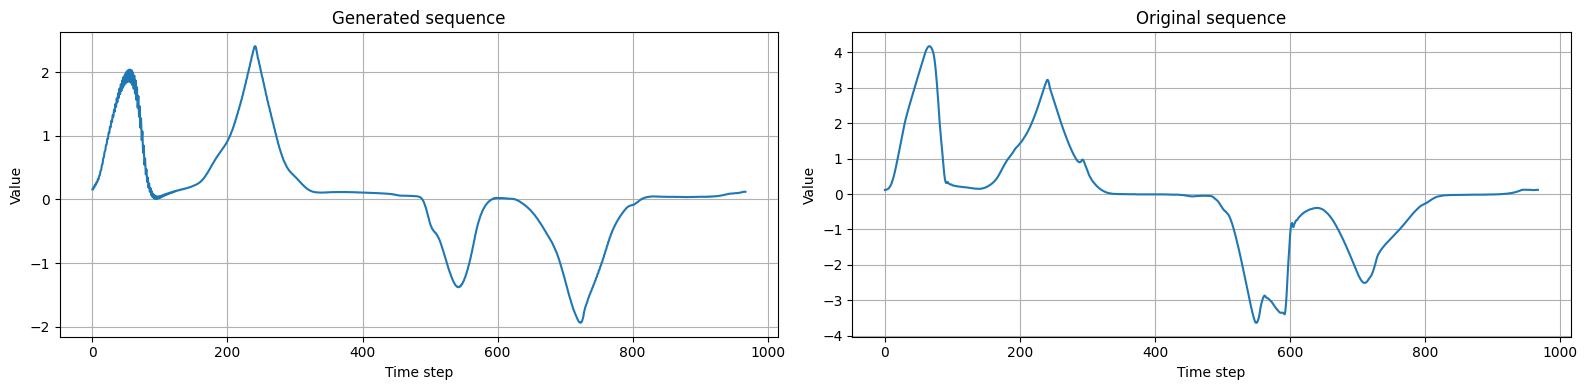

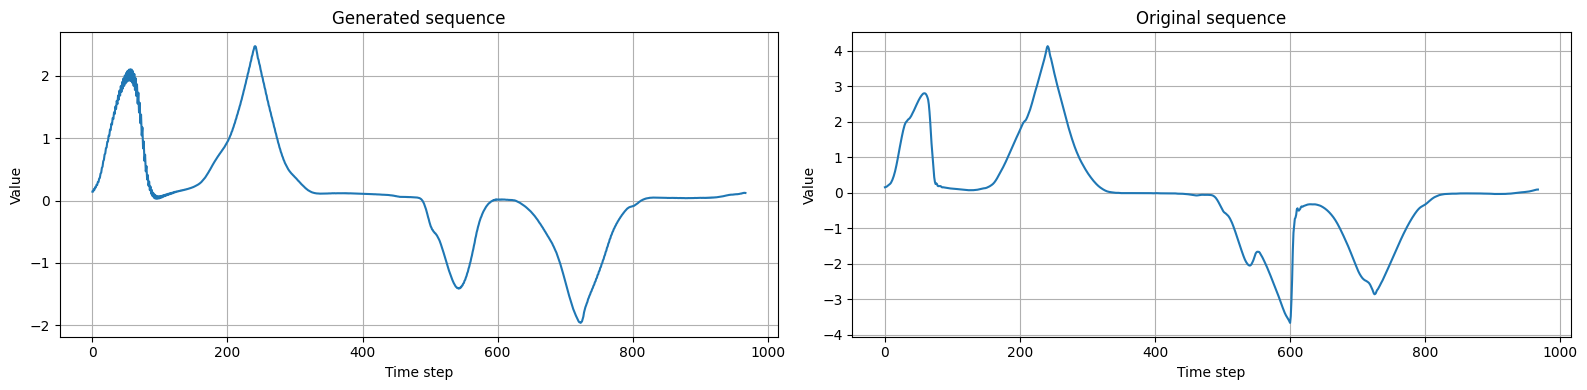

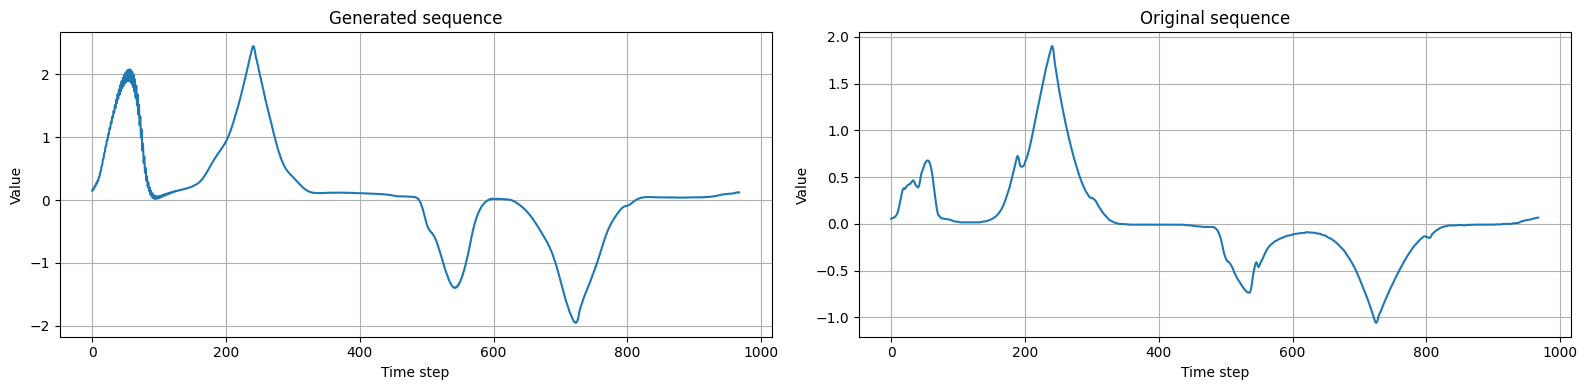

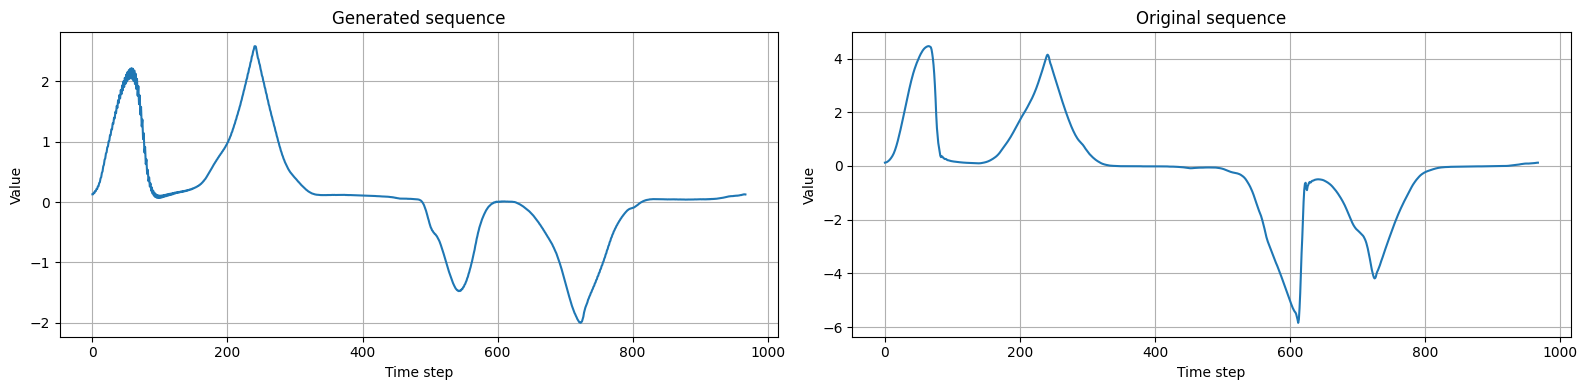

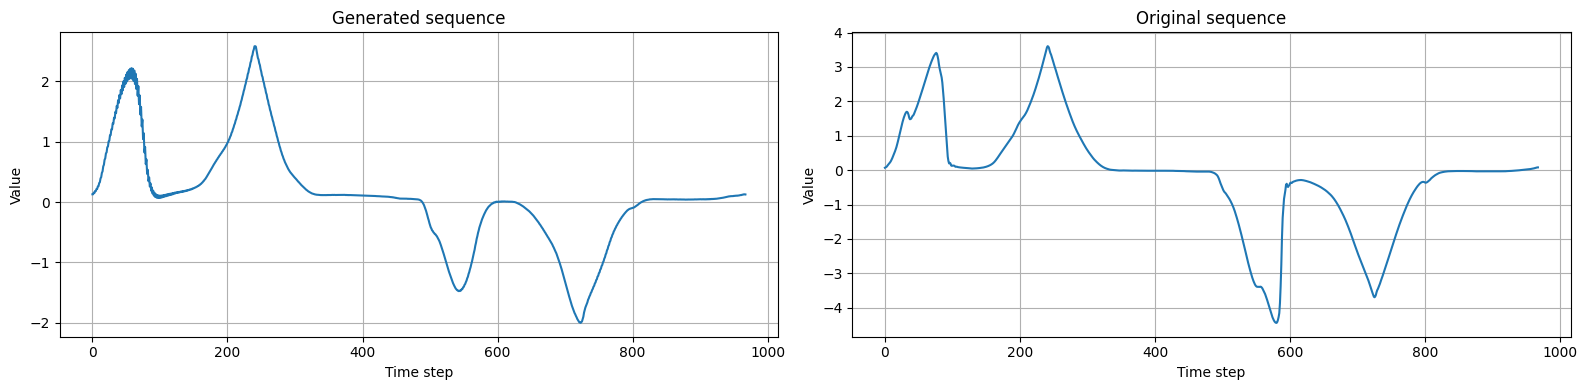

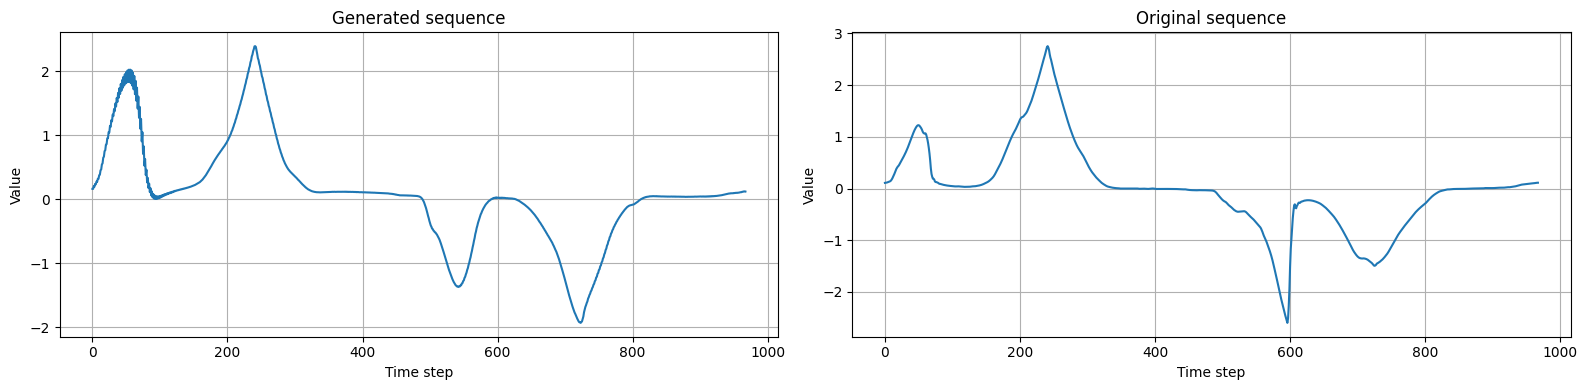

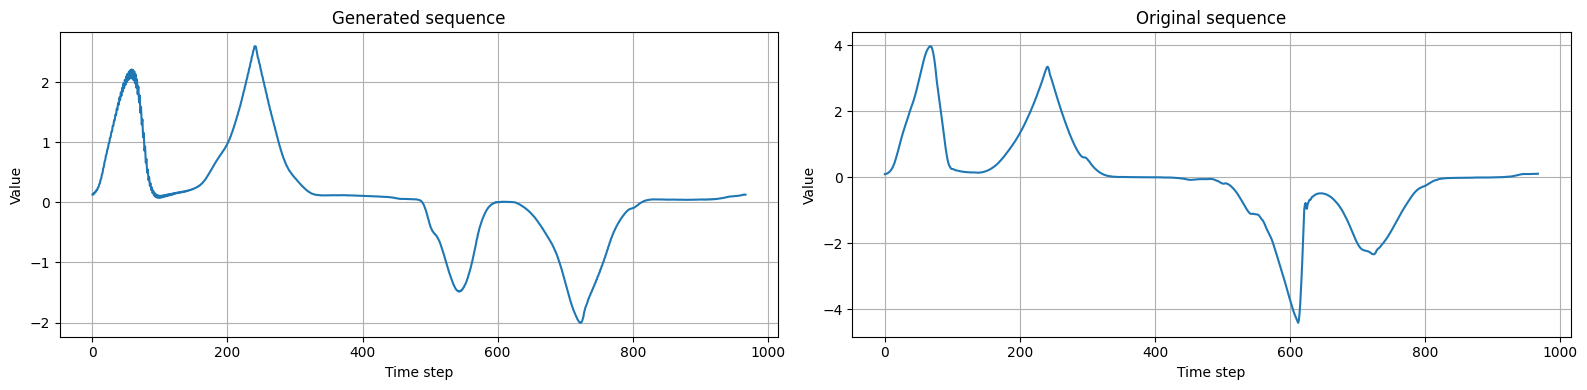

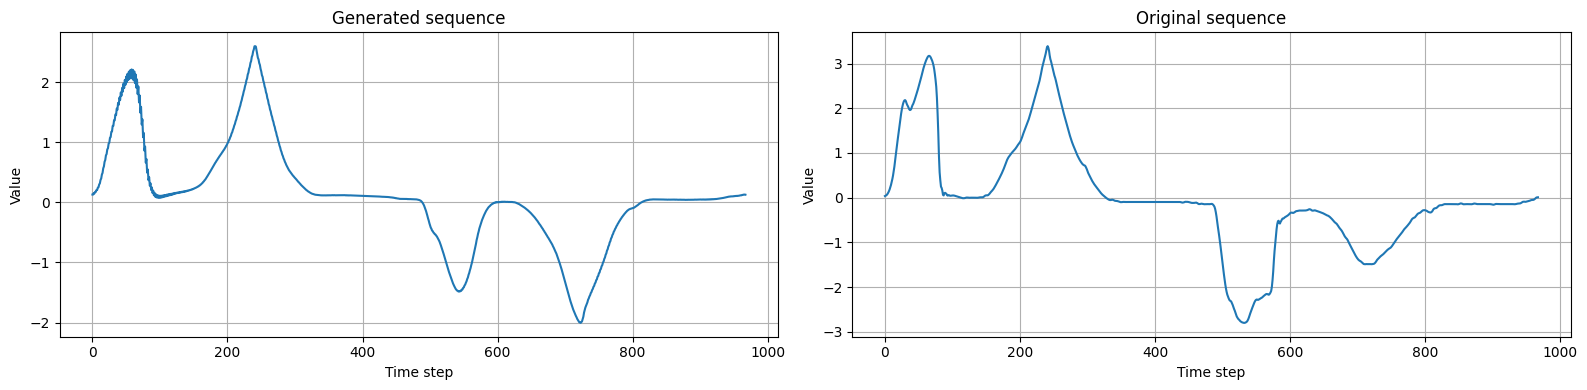

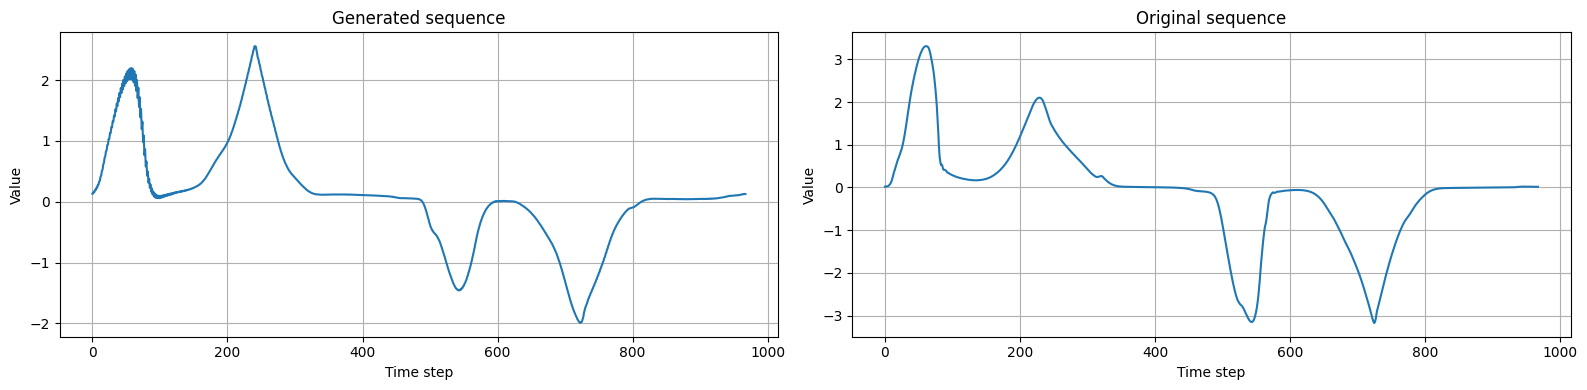

In [8]:
for idx in range(0, len(test_dataset)-1):
    generated_seq = vae.generate(
        desc=test_dataset[idx]['features'].unsqueeze(0).to(device), 
        conc=test_dataset[idx]['conc'].unsqueeze(0).to(device)
        ).squeeze(0).cpu().numpy()
    test_seq = test_dataset[idx]['vah'].cpu().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(16, 4))

    axs[0].plot(generated_seq)
    axs[0].set_title("Generated sequence")
    axs[0].set_xlabel("Time step")
    axs[0].set_ylabel("Value")
    axs[0].grid(True)

    axs[1].plot(test_seq)
    axs[1].set_title("Original sequence")
    axs[1].set_xlabel("Time step")
    axs[1].set_ylabel("Value")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

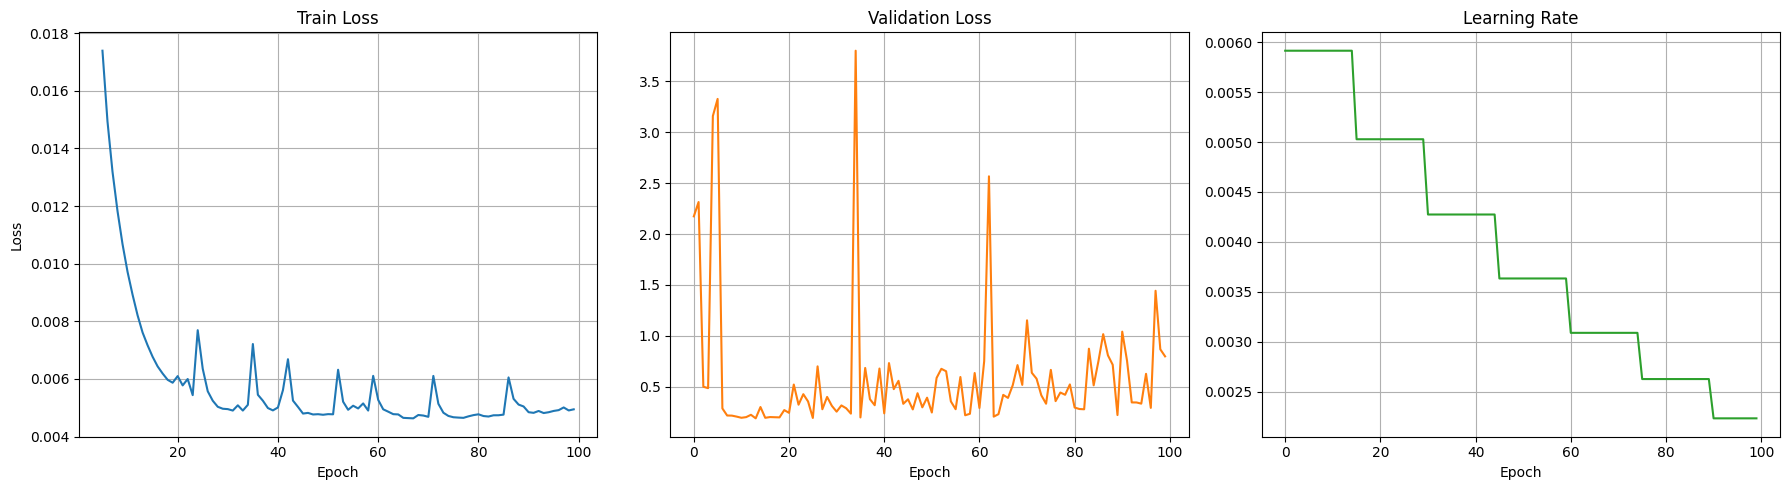

In [9]:
import re
import matplotlib.pyplot as plt

epochs = []
train_loss = []
val_loss = []
lr = []

pattern = re.compile(
    r"Epoch\s+(\d+)\s+—\s+Train Loss:\s+([\d.]+),\s+Val Loss:\s+([\d.]+),\s+LR:\s+\[([\d.eE+-]+)\]"
)

with open("temp1.txt", "r", encoding="utf-8") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            epochs.append(int(m.group(1)))
            train_loss.append(float(m.group(2)))
            val_loss.append(float(m.group(3)))
            lr.append(float(m.group(4)))

# данные для train loss начиная с 5 эпохи
start_epoch = 5
train_epochs = epochs[start_epoch:]
train_loss_cut = train_loss[start_epoch:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

# Train Loss
axes[0].plot(train_epochs, train_loss_cut, color="tab:blue")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Val Loss
axes[1].plot(epochs, val_loss, color="tab:orange")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].grid(True)

# Learning Rate
axes[2].plot(epochs, lr, color="tab:green")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].grid(True)

plt.tight_layout()
plt.show()


# Optuna

In [ ]:
import optuna
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
from datetime import datetime
import matplotlib.pyplot as plt

from data.datasets.universal_dataset import GPTDataset
from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path


INHIBITOR_NAME = "benzimidazole"
normalize = False

def load_data(drop_inhib: str):
    prep = Pipeline(
        num_cycle=[1, 2, 3, 4], 
        inhibitor_name="all", 
        split="all",
        norm_feat=True
    )
    data = prep.full_data

    train_data, valid_data = select_test_inh(data, drop_inhib)
    
    return train_data, valid_data

train, val = load_data(drop_inhib=INHIBITOR_NAME)
val = val.iloc[[850, 700, 600, 550, 500, 400, 350, 300, 150, 100], :]
train_dataset = GPTDataset(train)
test_dataset = GPTDataset(val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

device = "cuda:0" if torch.cuda.is_available() else "cpu"

def objective(trial):
    d_model = trial.suggest_int("d_model", 8, 64, step=8)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    num_heads = trial.suggest_int("num_heads", 1, 2)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    vae = GPT(
        chem_dim=train_dataset[0]['features'].shape[0],
        conc_dim=train_dataset[0]['conc'].shape[0],
        seq_len=train_dataset[0]['vah'].shape[0],
        d_model=d_model,
        nhead=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    opt_vae = torch.optim.Adam(vae.parameters(), lr=lr)
    scheduler = StepLR(opt_vae, gamma=0.85, step_size=15)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    trial_dir = os.path.join(get_project_path(), "reports", "gpt_optuna", INHIBITOR_NAME, f"trial_{trial.number}_{timestamp}")

    os.makedirs(trial_dir, exist_ok=True)
    model_path = os.path.join(trial_dir, "best_model.pt")

    trainer = Trainer(
        model=vae,
        loss_fn=vae_loss,
        epochs=50,
        optimizer=opt_vae,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        path_to_save_plots=trial_dir,
        path_to_save_models=model_path,
        path_to_save_tables=trial_dir,
        scheduler=scheduler,
        seed=42
    )

    trainer.train_model()

    best_val_loss = trainer.best_val_loss

    return best_val_loss

In [ ]:
study = optuna.create_study(
    direction="minimize",
    study_name="gpt_hyperparameter_opt",
    storage=None 
)
study.optimize(objective, n_trials=30)

print("Лучшие параметры:", study.best_params)
print("Лучшее значение loss:", study.best_value)